In [1]:
!pip -q install datasets

In [2]:
from datasets import load_dataset
import numpy as np
import pandas as pd

# Load the multispectral EuroSAT dataset
dataset = load_dataset(
    "blanchon/EuroSAT_MSI",
    split="train"
)

print(dataset)

README.md:   0%|          | 0.00/3.46k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  354MB            

data/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  360MB            

data/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

data/validation-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label', 'filename'],
    num_rows: 16200
})


In [3]:
N_SAMPLES = 600

sample = dataset.shuffle(seed=42).select(range(N_SAMPLES))

print(f"Samples loaded: {len(sample)}")
print("Image shape:", np.array(sample[0]["image"]).shape)
print("Data type:", np.array(sample[0]["image"]).dtype)

Samples loaded: 600
Image shape: (64, 64, 13)
Data type: int64


In [4]:
import numpy as np
import pandas as pd

def spectral_features(image):
    """
    Extract compact remote-sensing features from a
    13-band Sentinel-2 EuroSAT image.

    EuroSAT band order:
    B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9, B10, B11, B12
    """

    image = image.astype(np.float32)

    # Mean reflectance of each spectral band
    band_means = image.mean(axis=(0, 1))

    # Sentinel-2 indices
    B3 = image[:, :, 2]   # Green
    B4 = image[:, :, 3]   # Red
    B8 = image[:, :, 7]   # NIR
    B11 = image[:, :, 11] # SWIR

    eps = 1e-8

    NDVI = (B8 - B4) / (B8 + B4 + eps)
    NDWI = (B3 - B8) / (B3 + B8 + eps)
    NDBI = (B11 - B8) / (B11 + B8 + eps)

    features = np.concatenate([
        band_means,
        [
            NDVI.mean(),
            NDVI.std(),
            NDWI.mean(),
            NDWI.std(),
            NDBI.mean(),
            NDBI.std()
        ]
    ])

    return features


# Extract features from our 600 observations
X = np.array([
    spectral_features(np.array(row["image"]))
    for row in sample
])

print("Feature matrix:", X.shape)
print("Number of features:", X.shape[1])

Feature matrix: (600, 19)
Number of features: 19


In [5]:
feature_names = [
    "B1", "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B9", "B10", "B11", "B12",
    "NDVI_mean", "NDVI_std",
    "NDWI_mean", "NDWI_std",
    "NDBI_mean", "NDBI_std"
]

features_df = pd.DataFrame(X, columns=feature_names)

features_df.head()

,B1,B2,B3,B4,B5,B6,B7,B8,B8A,B9,B10,B11,B12,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDBI_mean,NDBI_std
0,1506.482910,1339.730713,1340.553711,1498.677490,1707.289795,2118.883301,2365.748535,2315.670410,819.812256,18.164062,2862.185303,1962.080566,2635.919678,0.216848,0.041760,-0.266924,0.023739,-0.086255,0.052653
1,1647.926758,1454.872070,1342.979980,1308.407959,1418.949951,1815.051025,1987.575195,1863.521973,546.293457,10.332764,1835.781982,1333.222656,2075.078369,0.185911,0.181467,-0.159792,0.150234,-0.153213,0.150683
2,1092.081055,773.046143,645.545410,386.311279,708.288574,2323.489746,3053.965332,3008.718750,1035.835449,8.255615,1438.952637,577.598877,3407.707764,0.769483,0.044179,-0.641734,0.045166,-0.677544,0.056652
3,1535.140381,1327.796387,1239.092285,1218.120361,1368.670166,1962.959473,2259.202637,2150.166992,491.875244,12.275635,2134.521729,1474.023438,2464.921387,0.273681,0.164432,-0.260931,0.135677,-0.179801,0.155468
4,1562.531738,1345.859375,1233.183594,1182.634521,1338.535889,1947.644287,2273.244873,2117.073730,419.953857,9.973633,1923.743408,1196.043701,2488.967773,0.289223,0.188822,-0.260855,0.157563,-0.270252,0.156353


In [6]:
features_df.describe().T

,count,mean,std,min,25%,50%,75%,max
B1,600.0,1359.898926,225.541000,864.789795,1190.059082,1336.421021,1487.999268,2139.739990
B2,600.0,1127.931641,259.949738,612.197021,922.243347,1100.346191,1311.027283,2087.738525
B3,600.0,1057.879395,311.186523,427.611572,857.516663,1013.281250,1243.124084,2098.936279
B4,600.0,973.796326,478.762024,237.550537,566.475586,884.906738,1276.687134,2497.350830
B5,600.0,1225.051270,482.033447,198.064209,928.370972,1198.978271,1502.999756,2638.812256
B6,600.0,2011.664429,707.934387,170.718262,1715.026794,2099.687744,2467.317688,3647.013916
B7,600.0,2375.120850,889.407166,148.072021,2011.331055,2468.199097,2920.954468,4798.290039
B8,600.0,2302.900391,884.166504,117.120850,1937.504944,2391.053467,2861.131653,4640.508789
B8A,600.0,737.149048,371.729706,51.884521,504.117065,725.297363,946.151428,1979.510742
B9,600.0,12.287690,4.292192,4.195312,9.407471,11.596802,14.294800,39.885986


In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the 19 features extracted in Cell 4
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Keep numerical values stable
X_scaled = np.nan_to_num(
    X_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print("Scaled observations:", X_scaled.shape)
print("Mean of first feature:", round(X_scaled[:, 0].mean(), 4))
print("Std of first feature:", round(X_scaled[:, 0].std(), 4))

Scaled observations: (600, 19)
Mean of first feature: 0.0
Std of first feature: 1.0


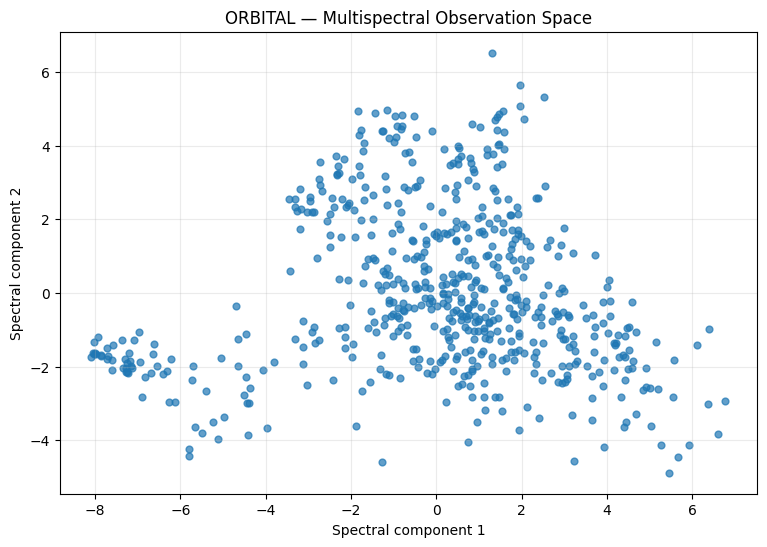

Variance represented by 2 components: 72.91 %


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    alpha=0.7,
    s=24
)

plt.xlabel("Spectral component 1")
plt.ylabel("Spectral component 2")
plt.title("ORBITAL — Multispectral Observation Space")
plt.grid(alpha=0.25)
plt.show()

print(
    "Variance represented by 2 components:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

In [9]:
from sklearn.cluster import MiniBatchKMeans

N_TARGETS = 8

region_model = MiniBatchKMeans(
    n_clusters=N_TARGETS,
    random_state=42,
    n_init=5,
    batch_size=128
)

target_ids = region_model.fit_predict(X_scaled)
target_features = region_model.cluster_centers_

print("Observation targets:", N_TARGETS)
print("Target feature matrix:", target_features.shape)
print("Samples per target:", np.bincount(target_ids))

Observation targets: 8
Target feature matrix: (8, 19)
Samples per target: [ 99 107  57  82  71  71  49  64]


In [11]:

# Representative spectral profiles from our eight targets
target_features = region_model.cluster_centers_

# Pairwise distances between target profiles
distance_matrix = np.linalg.norm(
    target_features[:, None, :] - target_features[None, :, :],
    axis=2
)

# Normalise distances for a stable reward scale
max_distance = distance_matrix.max()
if max_distance > 0:
    distance_matrix /= max_distance

np.fill_diagonal(distance_matrix, 0.0)

print("Distance matrix:", distance_matrix.shape)
print("Minimum distance:", round(distance_matrix.min(), 3))
print("Maximum distance:", round(distance_matrix.max(), 3))

Distance matrix: (8, 8)
Minimum distance: 0.0
Maximum distance: 1.0


In [12]:
class OrbitalEnv:
    def __init__(
        self,
        distance_matrix,
        budget=6,
        cloud_probability=0.20,
        observation_cost=0.10,
        seed=42
    ):
        self.distances = distance_matrix
        self.n_targets = len(distance_matrix)
        self.initial_budget = budget
        self.cloud_probability = cloud_probability
        self.observation_cost = observation_cost
        self.rng = np.random.default_rng(seed)

        self.reset()

    def reset(self):
        self.budget = self.initial_budget
        self.visited = set()
        self.last_target = 0
        return self._state()

    def _state(self):
        # Compact, discrete state suitable for tabular Q-learning
        return (
            self.last_target,
            tuple(sorted(self.visited)),
            self.budget
        )

    def step(self, action):
        if self.budget <= 0:
            raise RuntimeError("Episode is finished. Call reset().")

        action = int(action)
        self.budget -= 1

        reward = -self.observation_cost
        success = self.rng.random() >= self.cloud_probability

        if not success:
            reward -= 0.25  # failed observation wastes an opportunity

        elif action in self.visited:
            reward -= 0.50  # redundant observation

        else:
            if self.visited:
                novelty = min(
                    self.distances[action, previous]
                    for previous in self.visited
                )
            else:
                novelty = 1.0

            reward += float(novelty)
            self.visited.add(action)

        self.last_target = action
        next_state = self._state()
        done = self.budget == 0

        info = {
            "success": success,
            "unique_targets_observed": len(self.visited)
        }

        return next_state, reward, done, info


env = OrbitalEnv(distance_matrix)

state = env.reset()
next_state, reward, done, info = env.step(0)

print("Initial state:", state)
print("Next state:", next_state)
print("Reward:", round(reward, 3))
print("Observation details:", info)

Initial state: (0, (), 6)
Next state: (0, (0,), 5)
Reward: 0.9
Observation details: {'success': True, 'unique_targets_observed': 1}


In [13]:

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N_ACTIONS = env.n_targets

Q = defaultdict(lambda: np.zeros(N_ACTIONS))

ALPHA = 0.15
GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.999

N_EPISODES = 6000
rng = np.random.default_rng(123)

episode_rewards = []

for episode in range(N_EPISODES):
    state = env.reset()
    total_reward = 0.0
    done = False

    while not done:
        # Explore or choose the best-known action
        if rng.random() < EPSILON:
            action = int(rng.integers(N_ACTIONS))
        else:
            values = Q[state]
            best_actions = np.flatnonzero(
                np.isclose(values, values.max())
            )
            action = int(rng.choice(best_actions))

        next_state, reward, done, info = env.step(action)

        # Q-learning update
        future_value = 0.0 if done else np.max(Q[next_state])

        Q[state][action] += ALPHA * (
            reward
            + GAMMA * future_value
            - Q[state][action]
        )

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

print("Training complete!")
print("Episodes:", N_EPISODES)
print("States encountered:", len(Q))
print("Final epsilon:", round(EPSILON, 3))
print("Final episode reward:", round(episode_rewards[-1], 3))

Training complete!
Episodes: 6000
States encountered: 1748
Final epsilon: 0.05
Final episode reward: 1.452


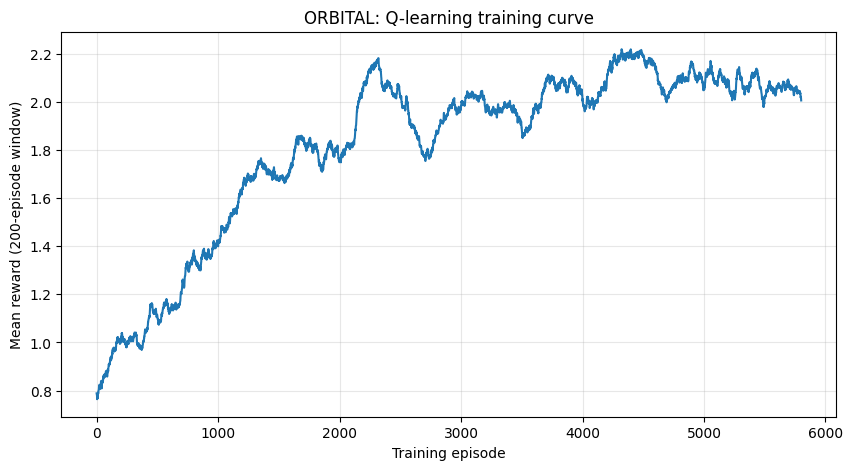

Early mean reward: 0.926
Final mean reward: 2.045


In [14]:

rewards = np.array(episode_rewards)
window = 200

moving_average = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average)
plt.xlabel("Training episode")
plt.ylabel("Mean reward (200-episode window)")
plt.title("ORBITAL: Q-learning training curve")
plt.grid(alpha=0.3)
plt.show()

print("Early mean reward:", round(rewards[:500].mean(), 3))
print("Final mean reward:", round(rewards[-500:].mean(), 3))

In [15]:

def evaluate_policy(policy, n_episodes=500, seed=1000):
    test_env = OrbitalEnv(
        distance_matrix,
        budget=6,
        cloud_probability=0.20,
        observation_cost=0.10,
        seed=seed
    )

    rng_eval = np.random.default_rng(seed + 1)
    returns = []
    unique_counts = []

    for _ in range(n_episodes):
        state = test_env.reset()
        total_reward = 0.0
        done = False

        while not done:
            if policy == "q_learning":
                values = Q[state]
                best = np.flatnonzero(
                    np.isclose(values, values.max())
                )
                action = int(rng_eval.choice(best))

            elif policy == "random":
                action = int(rng_eval.integers(N_ACTIONS))

            elif policy == "greedy":
                visited = set(state[1])
                available = [
                    i for i in range(N_ACTIONS)
                    if i not in visited
                ]

                if not available:
                    action = int(rng_eval.integers(N_ACTIONS))
                elif not visited:
                    action = int(rng_eval.choice(available))
                else:
                    novelty = {
                        i: min(
                            distance_matrix[i, j]
                            for j in visited
                        )
                        for i in available
                    }
                    best_value = max(novelty.values())
                    best = [
                        i for i, value in novelty.items()
                        if np.isclose(value, best_value)
                    ]
                    action = int(rng_eval.choice(best))
            else:
                raise ValueError("Unknown policy")

            state, reward, done, info = test_env.step(action)
            total_reward += reward

        returns.append(total_reward)
        unique_counts.append(len(test_env.visited))

    return {
        "Mean reward": np.mean(returns),
        "Reward std": np.std(returns),
        "Mean unique targets": np.mean(unique_counts)
    }


results = pd.DataFrame({
    name: evaluate_policy(name)
    for name in ["random", "greedy", "q_learning"]
}).T

display(results.round(3))

,Mean reward,Reward std,Mean unique targets
random,0.794,0.709,3.742
greedy,2.258,0.632,4.766
q_learning,2.210,0.764,4.766


In [16]:

# Compare reward distributions over more evaluation episodes

N_TESTS = 2000

extended_results = pd.DataFrame({
    name: evaluate_policy(name, n_episodes=N_TESTS, seed=2026)
    for name in ["random", "greedy", "q_learning"]
}).T

display(extended_results.round(3))

difference = (
    extended_results.loc["q_learning", "Mean reward"]
    - extended_results.loc["greedy", "Mean reward"]
)

print(f"Q-learning minus greedy reward: {difference:.3f}")

,Mean reward,Reward std,Mean unique targets
random,0.802,0.733,3.792
greedy,2.300,0.660,4.839
q_learning,2.266,0.773,4.839


Q-learning minus greedy reward: -0.033


ORBITAL v2

In [17]:
class OrbitalEnvV2:
    def __init__(
        self,
        distance_matrix,
        budget=6,
        observation_cost=0.10,
        seed=42
    ):
        self.distances = np.asarray(distance_matrix)
        self.n_targets = len(self.distances)
        self.initial_budget = budget
        self.observation_cost = observation_cost
        self.rng = np.random.default_rng(seed)

        # Explicitly simulated target-dependent cloud risks
        self.cloud_risk = np.linspace(0.10, 0.40, self.n_targets)

        # Simulated energy cost per target
        self.energy_cost = np.linspace(0.05, 0.20, self.n_targets)

        self.reset()

    def reset(self):
        self.budget = self.initial_budget
        self.visited = set()
        self.last_target = 0
        self.weather = int(self.rng.integers(0, 2))
        return self._state()

    def _state(self):
        return (
            self.last_target,
            tuple(sorted(self.visited)),
            self.budget,
            self.weather
        )

    def step(self, action):
        if self.budget <= 0:
            raise RuntimeError("Episode finished. Call reset().")

        action = int(action)
        if not 0 <= action < self.n_targets:
            raise ValueError("Invalid target index.")

        self.budget -= 1

        reward = -self.observation_cost - self.energy_cost[action]

        # Weather regime changes stochastically
        if self.rng.random() < 0.25:
            self.weather = 1 - self.weather

        cloud_probability = self.cloud_risk[action]
        if self.weather == 1:
            cloud_probability = min(0.90, cloud_probability + 0.25)

        success = self.rng.random() >= cloud_probability

        if not success:
            reward -= 0.25

        elif action in self.visited:
            reward -= 0.50

        else:
            if self.visited:
                novelty = min(
                    self.distances[action, previous]
                    for previous in self.visited
                )
            else:
                novelty = 1.0

            reward += float(novelty)
            self.visited.add(action)

        self.last_target = action
        next_state = self._state()
        done = self.budget == 0

        info = {
            "success": success,
            "weather_regime": self.weather,
            "cloud_probability": cloud_probability,
            "energy_cost": self.energy_cost[action],
            "unique_targets_observed": len(self.visited)
        }

        return next_state, reward, done, info


env_v2 = OrbitalEnvV2(distance_matrix, seed=42)

state = env_v2.reset()
next_state, reward, done, info = env_v2.step(0)

print("Initial state:", state)
print("Next state:", next_state)
print("Reward:", round(reward, 3))
print("Details:", info)

Initial state: (0, (), 6, 1)
Next state: (0, (0,), 5, 1)
Reward: 0.85
Details: {'success': np.True_, 'weather_regime': 1, 'cloud_probability': np.float64(0.35), 'energy_cost': np.float64(0.05), 'unique_targets_observed': 1}


In [18]:

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

N_ACTIONS = env_v2.n_targets

Q_v2 = defaultdict(lambda: np.zeros(N_ACTIONS))

ALPHA = 0.15
GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.999
N_EPISODES = 6000

training_rng = np.random.default_rng(123)
episode_rewards_v2 = []

for episode in range(N_EPISODES):
    state = env_v2.reset()
    total_reward = 0.0
    done = False

    while not done:
        if training_rng.random() < EPSILON:
            action = int(training_rng.integers(N_ACTIONS))
        else:
            values = Q_v2[state]
            best = np.flatnonzero(
                np.isclose(values, values.max())
            )
            action = int(training_rng.choice(best))

        next_state, reward, done, info = env_v2.step(action)

        future_value = (
            0.0 if done else np.max(Q_v2[next_state])
        )

        Q_v2[state][action] += ALPHA * (
            reward + GAMMA * future_value
            - Q_v2[state][action]
        )

        state = next_state
        total_reward += reward

    episode_rewards_v2.append(total_reward)
    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

print("Training complete!")
print("Episodes:", N_EPISODES)
print("States encountered:", len(Q_v2))
print("Final epsilon:", round(EPSILON, 3))
print("Final episode reward:", round(episode_rewards_v2[-1], 3))

Training complete!
Episodes: 6000
States encountered: 3144
Final epsilon: 0.05
Final episode reward: 1.823


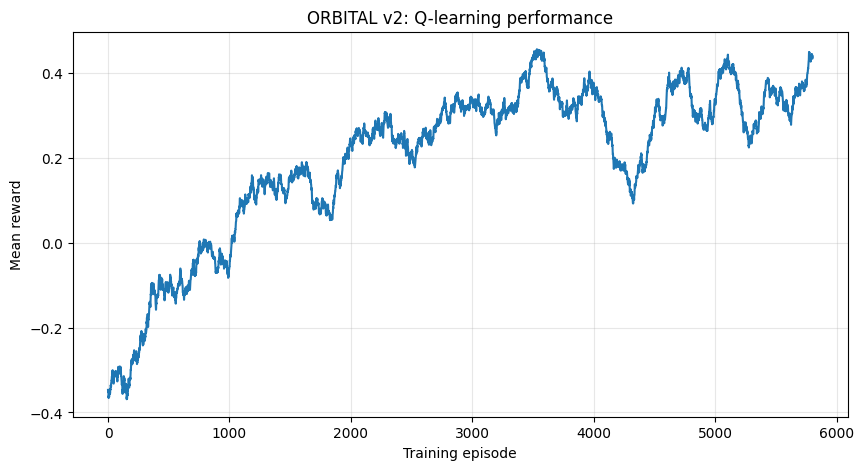

Early mean reward: -0.275
Final mean reward: 0.387


In [19]:

window = 200

moving_average_v2 = np.convolve(
    episode_rewards_v2,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))
plt.plot(moving_average_v2)
plt.xlabel("Training episode")
plt.ylabel("Mean reward")
plt.title("ORBITAL v2: Q-learning performance")
plt.grid(alpha=0.3)
plt.show()

print("Early mean reward:",
      round(np.mean(episode_rewards_v2[:500]), 3))
print("Final mean reward:",
      round(np.mean(episode_rewards_v2[-500:]), 3))

In [20]:

def evaluate_v2(policy, n_episodes=2000, seed=2026):
    test_env = OrbitalEnvV2(distance_matrix, seed=seed)
    rng_eval = np.random.default_rng(seed + 1)

    returns = []
    unique_counts = []

    for _ in range(n_episodes):
        state = test_env.reset()
        total_reward = 0.0
        done = False

        while not done:
            if policy == "q_learning":
                values = Q_v2[state]
                best = np.flatnonzero(
                    np.isclose(values, values.max())
                )
                action = int(rng_eval.choice(best))

            elif policy == "random":
                action = int(rng_eval.integers(N_ACTIONS))

            elif policy == "greedy":
                visited = set(state[1])
                available = [
                    i for i in range(N_ACTIONS)
                    if i not in visited
                ]

                if not available:
                    action = int(rng_eval.integers(N_ACTIONS))
                elif not visited:
                    action = int(rng_eval.choice(available))
                else:
                    novelty = {
                        i: min(
                            distance_matrix[i, j]
                            for j in visited
                        )
                        for i in available
                    }
                    best_value = max(novelty.values())
                    best = [
                        i for i, value in novelty.items()
                        if np.isclose(value, best_value)
                    ]
                    action = int(rng_eval.choice(best))
            else:
                raise ValueError("Unknown policy")

            state, reward, done, info = test_env.step(action)
            total_reward += reward

        returns.append(total_reward)
        unique_counts.append(len(test_env.visited))

    return {
        "Mean reward": np.mean(returns),
        "Reward std": np.std(returns),
        "Mean unique targets": np.mean(unique_counts)
    }


results_v2 = pd.DataFrame({
    name: evaluate_v2(name)
    for name in ["random", "greedy", "q_learning"]
}).T

display(results_v2.round(3))

,Mean reward,Reward std,Mean unique targets
random,-0.328,0.751,3.084
greedy,0.524,1.002,3.553
q_learning,0.536,0.683,3.929


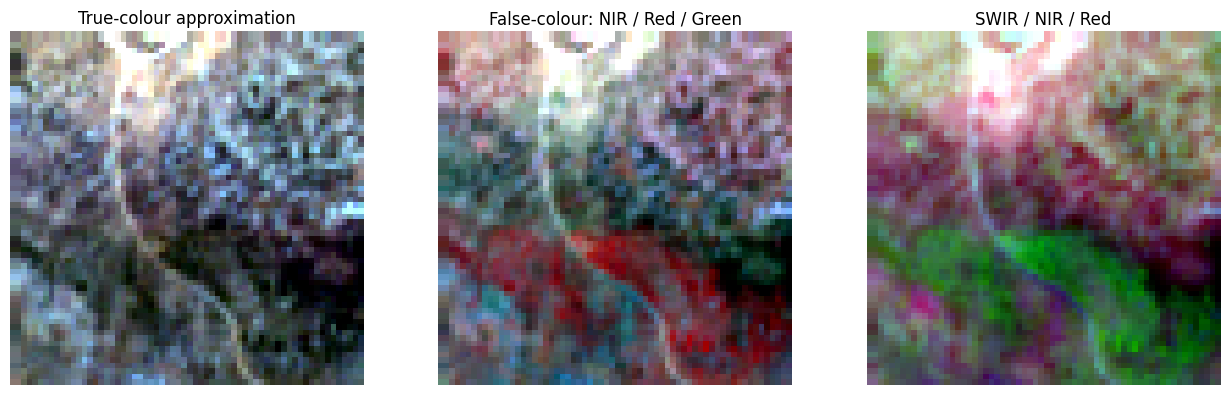

Patch shape: (64, 64, 13)
Sample index: 0


In [21]:

import numpy as np
import matplotlib.pyplot as plt

# Sentinel-2 MSI band indices in this dataset:
# B2 = Blue, B3 = Green, B4 = Red,
# B8 = NIR, B11 = SWIR1, B12 = SWIR2

def percentile_stretch(image, low=2, high=98):
    image = image.astype(np.float32)
    lo, hi = np.percentile(image, [low, high])
    if hi <= lo:
        return np.zeros_like(image)
    return np.clip((image - lo) / (hi - lo), 0, 1)

def make_composite(image, band_indices):
    channels = [
        percentile_stretch(image[:, :, b])
        for b in band_indices
    ]
    return np.stack(channels, axis=-1)

# Select a sample patch from the loaded EuroSAT sample.
sample_index = 0
image = np.asarray(sample[sample_index]["image"])

# True-colour approximation: Red, Green, Blue
true_colour = make_composite(image, [3, 2, 1])

# False-colour: NIR, Red, Green
# Healthy vegetation often appears bright red.
false_colour = make_composite(image, [7, 3, 2])

# SWIR, NIR, Red: another useful land-cover composite
swir_composite = make_composite(image, [11, 7, 3])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(true_colour)
axes[0].set_title("True-colour approximation")
axes[1].imshow(false_colour)
axes[1].set_title("False-colour: NIR / Red / Green")
axes[2].imshow(swir_composite)
axes[2].set_title("SWIR / NIR / Red")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Patch shape:", image.shape)
print("Sample index:", sample_index)

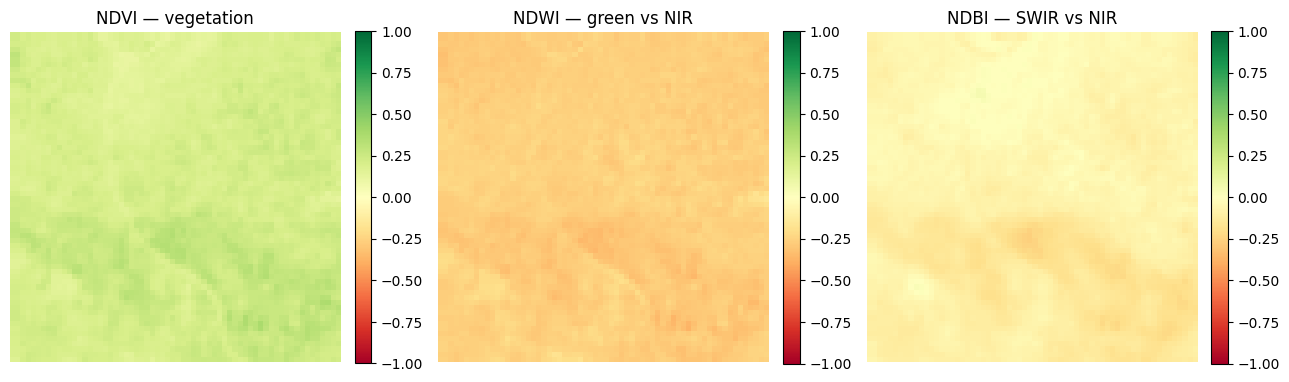

Mean NDVI: 0.217
Mean NDWI: -0.267
Mean NDBI: -0.086


In [22]:

image_f = image.astype(np.float32)

B3 = image_f[:, :, 2]   # Green
B4 = image_f[:, :, 3]   # Red
B8 = image_f[:, :, 7]   # Near-infrared
B11 = image_f[:, :, 11] # SWIR1

eps = 1e-8

ndvi = (B8 - B4) / (B8 + B4 + eps)
ndwi = (B3 - B8) / (B3 + B8 + eps)
ndbi = (B11 - B8) / (B11 + B8 + eps)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, data, title in zip(
    axes,
    [ndvi, ndwi, ndbi],
    ["NDVI — vegetation", "NDWI — green vs NIR", "NDBI — SWIR vs NIR"]
):
    im = ax.imshow(data, cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Mean NDVI:", round(float(ndvi.mean()), 3))
print("Mean NDWI:", round(float(ndwi.mean()), 3))
print("Mean NDBI:", round(float(ndbi.mean()), 3))

Mean spectral indices by target:


,NDVI_mean,NDWI_mean,NDBI_mean
target,,,
0,0.263,-0.245,-0.184
1,0.454,-0.391,-0.338
2,-0.240,0.446,-0.743
3,0.321,-0.348,-0.178
4,0.641,-0.555,-0.529
5,0.699,-0.559,-0.643
6,0.241,-0.118,-0.442
7,0.218,-0.274,-0.129


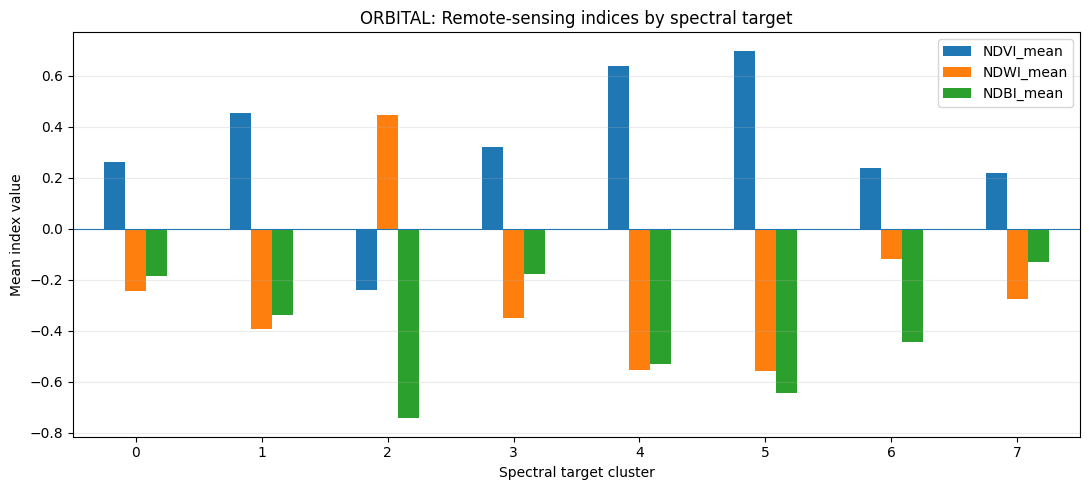

In [23]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# X contains the 19 spectral features extracted earlier.
# target_ids identifies the eight spectral clusters.
feature_names = (
    [f"B{i}_mean" for i in range(1, 14)]
    + [
        "NDVI_mean", "NDVI_std",
        "NDWI_mean", "NDWI_std",
        "NDBI_mean", "NDBI_std"
    ]
)

cluster_df = pd.DataFrame(X, columns=feature_names)
cluster_df["target"] = target_ids

index_means = (
    cluster_df.groupby("target")[
        ["NDVI_mean", "NDWI_mean", "NDBI_mean"]
    ].mean()
)

print("Mean spectral indices by target:")
display(index_means.round(3))

index_means.plot(kind="bar", figsize=(11, 5))
plt.axhline(0, linewidth=0.8)
plt.title("ORBITAL: Remote-sensing indices by spectral target")
plt.xlabel("Spectral target cluster")
plt.ylabel("Mean index value")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [24]:

print(
    index_means.sort_values("NDWI_mean", ascending=False)
    .round(3)
    .to_string()
)

print("\nTargets with positive mean NDWI:")
print(index_means.index[index_means["NDWI_mean"] > 0].tolist())

        NDVI_mean  NDWI_mean  NDBI_mean
target                                 
2          -0.240      0.446     -0.743
6           0.241     -0.118     -0.442
0           0.263     -0.245     -0.184
7           0.218     -0.274     -0.129
3           0.321     -0.348     -0.178
1           0.454     -0.391     -0.338
4           0.641     -0.555     -0.529
5           0.699     -0.559     -0.643

Targets with positive mean NDWI:
[2]


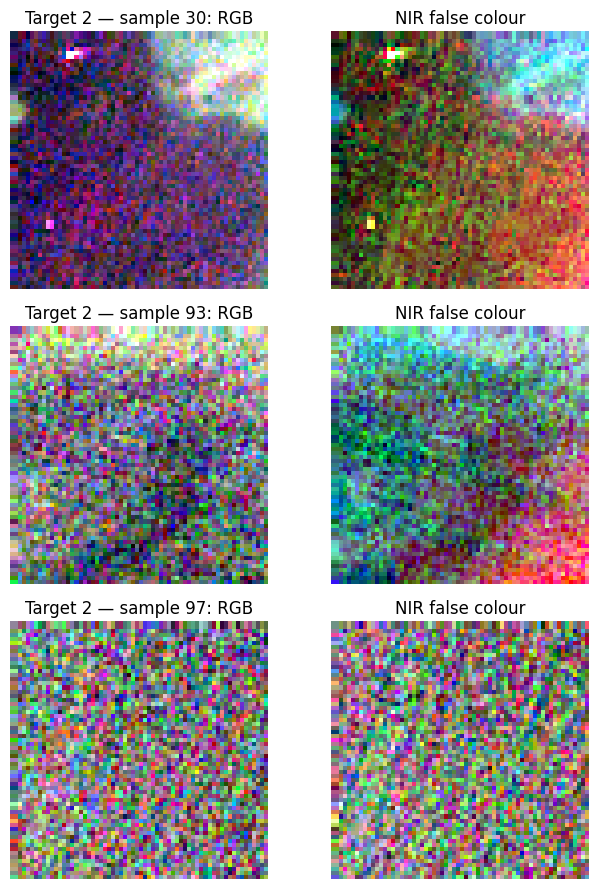

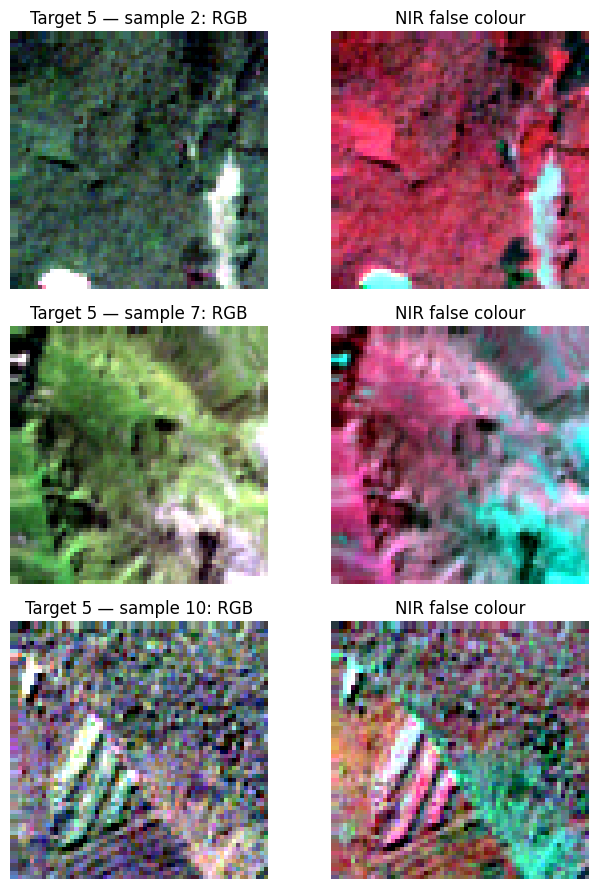

In [25]:

# Display representative samples from Target 2 and Target 5.
# These are spectral clusters, not geographic regions.

for target in [2, 5]:
    indices = np.flatnonzero(target_ids == target)[:3]

    fig, axes = plt.subplots(
        len(indices), 2, figsize=(7, 3 * len(indices))
    )
    axes = np.atleast_2d(axes)

    for row_idx, sample_idx in enumerate(indices):
        img = np.asarray(sample[sample_idx]["image"])

        rgb = make_composite(img, [3, 2, 1])
        false_colour = make_composite(img, [7, 3, 2])

        axes[row_idx, 0].imshow(rgb)
        axes[row_idx, 0].set_title(
            f"Target {target} — sample {sample_idx}: RGB"
        )
        axes[row_idx, 1].imshow(false_colour)
        axes[row_idx, 1].set_title("NIR false colour")

        for ax in axes[row_idx]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

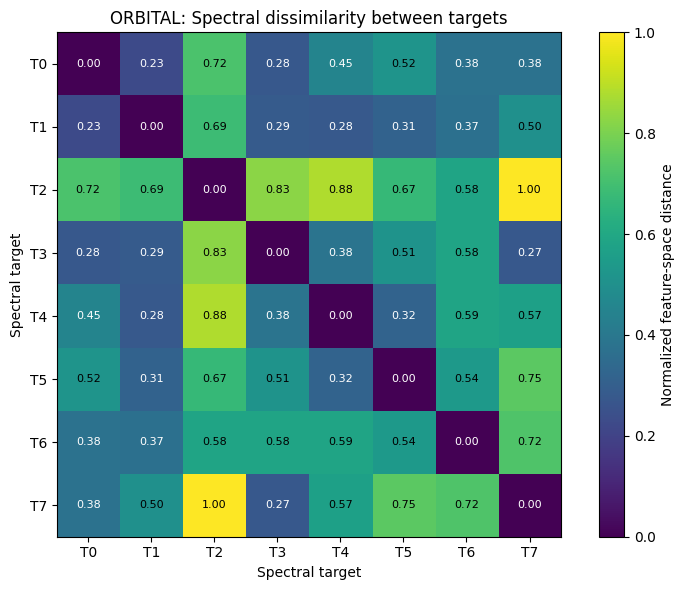

In [26]:

# target_features contains the 8 standardized cluster centroids.
# distance_matrix measures normalized spectral dissimilarity.
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(distance_matrix, cmap="viridis", vmin=0, vmax=1)

ax.set_xticks(range(N_TARGETS))
ax.set_yticks(range(N_TARGETS))
ax.set_xticklabels([f"T{i}" for i in range(N_TARGETS)])
ax.set_yticklabels([f"T{i}" for i in range(N_TARGETS)])
ax.set_xlabel("Spectral target")
ax.set_ylabel("Spectral target")
ax.set_title("ORBITAL: Spectral dissimilarity between targets")

for i in range(N_TARGETS):
    for j in range(N_TARGETS):
        ax.text(j, i, f"{distance_matrix[i, j]:.2f}",
                ha="center", va="center",
                color="white" if distance_matrix[i, j] < 0.5 else "black",
                fontsize=8)

fig.colorbar(im, ax=ax, label="Normalized feature-space distance")
plt.tight_layout()
plt.show()

In [28]:


def evaluate_diversity_v2(policy, n_episodes=1000, seed=3030):
    test_env = OrbitalEnvV2(distance_matrix, seed=seed)
    rng_eval = np.random.default_rng(seed + 1)

    diversity_scores = []
    unique_counts = []

    for _ in range(n_episodes):
        state = test_env.reset()
        done = False

        while not done:
            if policy == "q_learning":
                values = Q_v2[state]
                best = np.flatnonzero(
                    np.isclose(values, values.max())
                )
                action = int(rng_eval.choice(best))

            elif policy == "random":
                action = int(rng_eval.integers(N_ACTIONS))

            elif policy == "greedy":
                visited = set(state[1])
                available = [
                    i for i in range(N_ACTIONS)
                    if i not in visited
                ]

                if not available:
                    action = int(rng_eval.integers(N_ACTIONS))
                elif not visited:
                    action = int(rng_eval.choice(available))
                else:
                    novelty = {
                        i: min(distance_matrix[i, j] for j in visited)
                        for i in available
                    }
                    max_novelty = max(novelty.values())
                    best = [
                        i for i, v in novelty.items()
                        if np.isclose(v, max_novelty)
                    ]
                    action = int(rng_eval.choice(best))
            else:
                raise ValueError("Unknown policy")

            state, reward, done, info = test_env.step(action)

        chosen = sorted(test_env.visited)
        unique_counts.append(len(chosen))

        if len(chosen) >= 2:
            distances = [
                distance_matrix[a, b]
                for i, a in enumerate(chosen)
                for b in chosen[i + 1:]
            ]
            diversity_scores.append(float(np.mean(distances)))
        else:
            diversity_scores.append(0.0)

    return {
        "Mean unique targets": np.mean(unique_counts),
        "Mean pairwise diversity": np.mean(diversity_scores),
        "Diversity std": np.std(diversity_scores)
    }


diversity_results = pd.DataFrame({
    policy: evaluate_diversity_v2(policy)
    for policy in ["random", "greedy", "q_learning"]
}).T

display(diversity_results.round(3))

,Mean unique targets,Mean pairwise diversity,Diversity std
random,3.086,0.480,0.194
greedy,3.579,0.661,0.184
q_learning,3.950,0.514,0.114


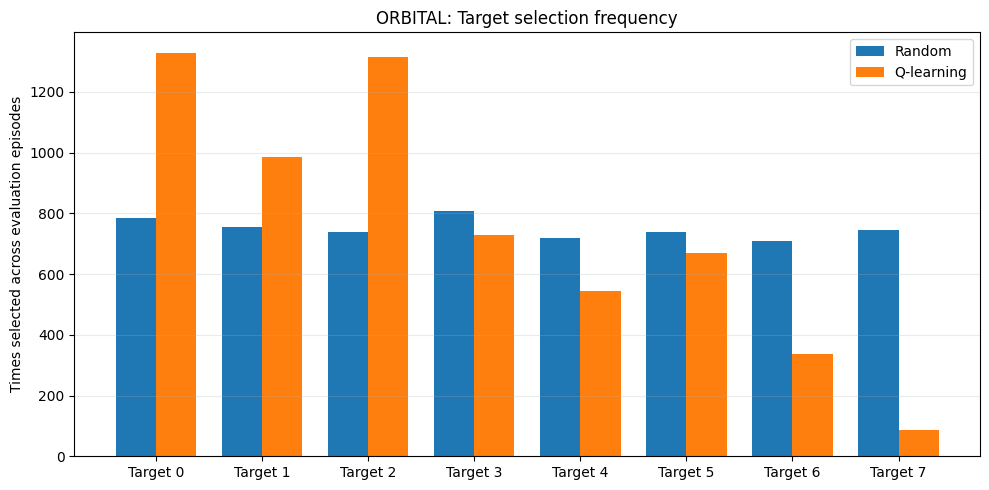

Q-learning selection counts: {0: 1330, 1: 985, 2: 1316, 3: 730, 4: 546, 5: 668, 6: 337, 7: 88}


In [29]:

def collect_target_selections(policy, n_episodes=1000, seed=4040):
    test_env = OrbitalEnvV2(distance_matrix, seed=seed)
    rng_eval = np.random.default_rng(seed + 1)
    counts = Counter()

    for _ in range(n_episodes):
        state = test_env.reset()
        done = False

        while not done:
            if policy == "q_learning":
                values = Q_v2[state]
                best = np.flatnonzero(
                    np.isclose(values, values.max())
                )
                action = int(rng_eval.choice(best))
            elif policy == "random":
                action = int(rng_eval.integers(N_ACTIONS))
            else:
                raise ValueError("Use 'q_learning' or 'random'")

            counts[action] += 1
            state, reward, done, info = test_env.step(action)

    return counts

q_counts = collect_target_selections("q_learning")
random_counts = collect_target_selections("random")

targets = np.arange(N_ACTIONS)
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(targets - width/2,
        [random_counts[i] for i in targets],
        width, label="Random")
plt.bar(targets + width/2,
        [q_counts[i] for i in targets],
        width, label="Q-learning")

plt.xticks(targets, [f"Target {i}" for i in targets])
plt.ylabel("Times selected across evaluation episodes")
plt.title("ORBITAL: Target selection frequency")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Q-learning selection counts:", dict(sorted(q_counts.items())))

In [31]:

import pandas as pd
import numpy as np

# X: 600 samples x 19 spectral features
# target_ids: spectral cluster assignment for each sample
# index_means: cluster means from Cell 20

target_summary = index_means.copy()
target_summary["Sample count"] = (
    pd.Series(target_ids).value_counts()
    .reindex(target_summary.index)
    .fillna(0).astype(int)
)

target_summary["Mean distance to other targets"] = [
    np.mean([
        distance_matrix[i, j]
        for j in range(N_TARGETS) if j != i
    ])
    for i in target_summary.index
]

target_summary = target_summary.sort_values(
    "NDVI_mean", ascending=False
)

print("ORBITAL — final spectral target summary")
display(target_summary.round(3))

print("\nTotal image patches:", len(X))
print("Spectral targets:", N_TARGETS)
print("Features per patch:", X.shape[1])
print("RL evaluation episodes per policy:", 1000)

ORBITAL — final spectral target summary


,NDVI_mean,NDWI_mean,NDBI_mean,Sample count,Mean distance to other targets
target,,,,,
5,0.699,-0.559,-0.643,71,0.517
4,0.641,-0.555,-0.529,71,0.496
1,0.454,-0.391,-0.338,107,0.380
3,0.321,-0.348,-0.178,82,0.449
0,0.263,-0.245,-0.184,99,0.420
6,0.241,-0.118,-0.442,49,0.537
7,0.218,-0.274,-0.129,64,0.599
2,-0.240,0.446,-0.743,57,0.766



Total image patches: 600
Spectral targets: 8
Features per patch: 19
RL evaluation episodes per policy: 1000


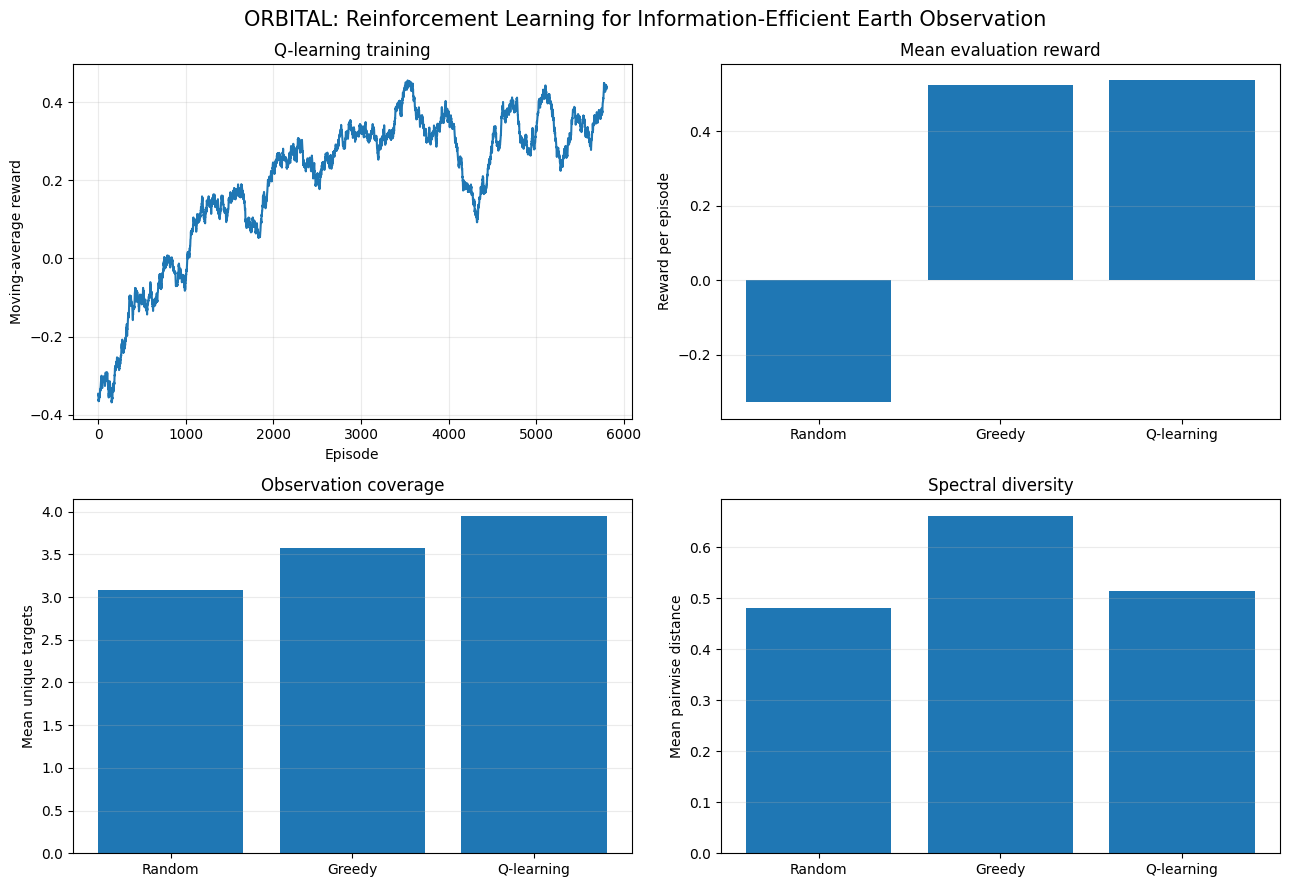

Saved figure: orbital_results.png


In [33]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Learning curve
window = 200
learning_curve = np.convolve(
    episode_rewards_v2,
    np.ones(window) / window,
    mode="valid"
)
axes[0, 0].plot(learning_curve)
axes[0, 0].set_title("Q-learning training")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Moving-average reward")
axes[0, 0].grid(alpha=0.25)

# 2. Evaluation rewards
policy_names = ["random", "greedy", "q_learning"]
reward_values = [
    results_v2.loc[p, "Mean reward"] for p in policy_names
]
axes[0, 1].bar(
    ["Random", "Greedy", "Q-learning"], reward_values
)
axes[0, 1].set_title("Mean evaluation reward")
axes[0, 1].set_ylabel("Reward per episode")
axes[0, 1].grid(axis="y", alpha=0.25)

# 3. Successfully observed unique targets
unique_values = [
    diversity_results.loc[p, "Mean unique targets"]
    for p in policy_names
]
axes[1, 0].bar(
    ["Random", "Greedy", "Q-learning"], unique_values
)
axes[1, 0].set_title("Observation coverage")
axes[1, 0].set_ylabel("Mean unique targets")
axes[1, 0].grid(axis="y", alpha=0.25)

# 4. Pairwise spectral diversity
diversity_values = [
    diversity_results.loc[p, "Mean pairwise diversity"]
    for p in policy_names
]
axes[1, 1].bar(
    ["Random", "Greedy", "Q-learning"], diversity_values
)
axes[1, 1].set_title("Spectral diversity")
axes[1, 1].set_ylabel("Mean pairwise distance")
axes[1, 1].grid(axis="y", alpha=0.25)

fig.suptitle(
    "ORBITAL: Reinforcement Learning for "
    "Information-Efficient Earth Observation",
    fontsize=15
)
plt.tight_layout()
plt.savefig("orbital_results.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure: orbital_results.png")

In [37]:

def epsilon_greedy_action(Q, state, rng, epsilon, n_actions):
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))

    values = Q[state]
    best = np.flatnonzero(np.isclose(values, values.max()))
    return int(rng.choice(best))


def train_sarsa(n_episodes=6000, seed=515):
    agent = defaultdict(lambda: np.zeros(N_ACTIONS))
    rng = np.random.default_rng(seed)

    alpha = 0.15
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.999

    train_env = OrbitalEnvV2(distance_matrix, seed=seed + 1)
    rewards = []

    for episode in range(n_episodes):
        state = train_env.reset()

        action = epsilon_greedy_action(
            agent, state, rng, epsilon, N_ACTIONS
        )

        total_reward = 0.0
        done = False

        while not done:
            next_state, reward, done, info = train_env.step(action)

            if done:
                target = reward
            else:
                next_action = epsilon_greedy_action(
                    agent, next_state, rng, epsilon, N_ACTIONS
                )
                target = reward + gamma * agent[next_state][next_action]

            agent[state][action] += alpha * (
                target - agent[state][action]
            )

            state = next_state
            total_reward += reward

            if not done:
                action = next_action

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return agent, rewards


Q_sarsa, sarsa_rewards = train_sarsa()

print("SARSA training complete")
print("Episodes:", len(sarsa_rewards))
print("States encountered:", len(Q_sarsa))
print("Early mean reward:", round(np.mean(sarsa_rewards[:500]), 3))
print("Final mean reward:", round(np.mean(sarsa_rewards[-500:]), 3))

SARSA training complete
Episodes: 6000
States encountered: 3129
Early mean reward: -0.297
Final mean reward: 0.395


In [36]:

def epsilon_greedy_action(Q, state, rng, epsilon, n_actions):
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))

    values = Q[state]
    best = np.flatnonzero(np.isclose(values, values.max()))
    return int(rng.choice(best))


def train_sarsa(n_episodes=6000, seed=515):
    agent = defaultdict(lambda: np.zeros(N_ACTIONS))
    rng = np.random.default_rng(seed)

    alpha = 0.15
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.999

    train_env = OrbitalEnvV2(distance_matrix, seed=seed + 1)
    rewards = []

    for episode in range(n_episodes):
        state = train_env.reset()

        action = epsilon_greedy_action(
            agent, state, rng, epsilon, N_ACTIONS
        )

        total_reward = 0.0
        done = False

        while not done:
            next_state, reward, done, info = train_env.step(action)

            if done:
                target = reward
            else:
                next_action = epsilon_greedy_action(
                    agent, next_state, rng, epsilon, N_ACTIONS
                )
                target = reward + gamma * agent[next_state][next_action]

            agent[state][action] += alpha * (
                target - agent[state][action]
            )

            state = next_state
            total_reward += reward

            if not done:
                action = next_action

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return agent, rewards


Q_sarsa, sarsa_rewards = train_sarsa()

print("SARSA training complete")
print("Episodes:", len(sarsa_rewards))
print("States encountered:", len(Q_sarsa))
print("Early mean reward:", round(np.mean(sarsa_rewards[:500]), 3))
print("Final mean reward:", round(np.mean(sarsa_rewards[-500:]), 3))

SARSA training complete
Episodes: 6000
States encountered: 3129
Early mean reward: -0.297
Final mean reward: 0.395


In [38]:

def evaluate_rl_agent(agent, n_episodes=2000, seed=6060):
    test_env = OrbitalEnvV2(distance_matrix, seed=seed)
    rng_eval = np.random.default_rng(seed + 1)

    returns = []
    unique_counts = []

    for _ in range(n_episodes):
        state = test_env.reset()
        total_reward = 0.0
        done = False

        while not done:
            values = agent[state]
            best = np.flatnonzero(
                np.isclose(values, values.max())
            )
            action = int(rng_eval.choice(best))

            state, reward, done, info = test_env.step(action)
            total_reward += reward

        returns.append(total_reward)
        unique_counts.append(len(test_env.visited))

    return {
        "Mean reward": np.mean(returns),
        "Reward std": np.std(returns),
        "Mean unique targets": np.mean(unique_counts)
    }


rl_comparison = pd.DataFrame({
    "Q-learning": evaluate_rl_agent(Q_v2, seed=6060),
    "SARSA": evaluate_rl_agent(Q_sarsa, seed=6060)
}).T

display(rl_comparison.round(3))

,Mean reward,Reward std,Mean unique targets
Q-learning,0.550,0.66,3.952
SARSA,0.421,0.61,3.760


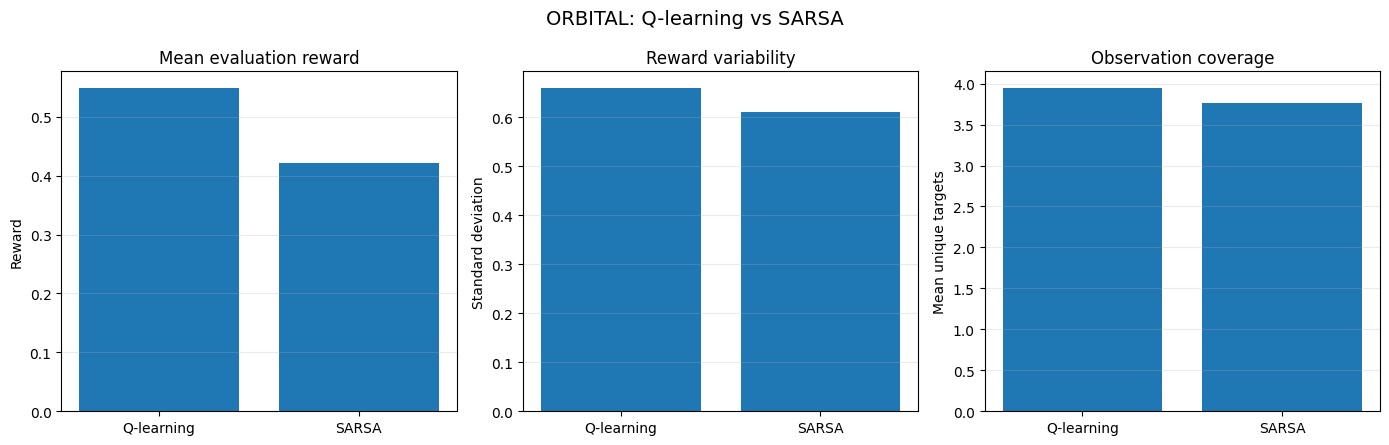

Saved orbital_rl_comparison.png


In [39]:

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

agents = ["Q-learning", "SARSA"]
colors = None  # Use Matplotlib's default colour cycle.

# Results from the held-out evaluation
mean_rewards = [
    rl_comparison.loc["Q-learning", "Mean reward"],
    rl_comparison.loc["SARSA", "Mean reward"]
]
reward_stds = [
    rl_comparison.loc["Q-learning", "Reward std"],
    rl_comparison.loc["SARSA", "Reward std"]
]
unique_targets = [
    rl_comparison.loc["Q-learning", "Mean unique targets"],
    rl_comparison.loc["SARSA", "Mean unique targets"]
]

axes[0].bar(agents, mean_rewards)
axes[0].set_title("Mean evaluation reward")
axes[0].set_ylabel("Reward")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(agents, reward_stds)
axes[1].set_title("Reward variability")
axes[1].set_ylabel("Standard deviation")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(agents, unique_targets)
axes[2].set_title("Observation coverage")
axes[2].set_ylabel("Mean unique targets")
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle("ORBITAL: Q-learning vs SARSA", fontsize=14)
plt.tight_layout()
plt.savefig("orbital_rl_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved orbital_rl_comparison.png")

In [40]:

import os
import pickle
import json

os.makedirs("orbital_models", exist_ok=True)

# Save both trained RL agents and the remote-sensing preprocessing models.
models = {
    "q_learning": dict(Q_v2),
    "sarsa": dict(Q_sarsa),
    "scaler": scaler,
    "region_model": region_model,
    "target_features": target_features,
    "distance_matrix": distance_matrix,
}

with open("orbital_models/orbital_models.pkl", "wb") as f:
    pickle.dump(models, f, protocol=pickle.HIGHEST_PROTOCOL)

# Save experiment configuration and feature metadata.
metadata = {
    "project": "ORBITAL",
    "n_samples": int(len(X)),
    "n_features": int(X.shape[1]),
    "n_targets": int(N_TARGETS),
    "rl_budget": 6,
    "cloud_model": "Simulated target-dependent cloud risk and two weather regimes",
    "algorithms": ["Q-learning", "SARSA"],
    "feature_names": feature_names
}

with open("orbital_models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("orbital_models/orbital_models.pkl")
print("orbital_models/metadata.json")
print("Q-learning states:", len(Q_v2))
print("SARSA states:", len(Q_sarsa))

Saved:
orbital_models/orbital_models.pkl
orbital_models/metadata.json
Q-learning states: 3171
SARSA states: 3140


In [41]:

with open("orbital_models/orbital_models.pkl", "rb") as f:
    loaded_models = pickle.load(f)

Q_loaded = loaded_models["q_learning"]
SARSA_loaded = loaded_models["sarsa"]

print("Q-learning states loaded:", len(Q_loaded))
print("SARSA states loaded:", len(SARSA_loaded))
print("Scaler loaded:", hasattr(loaded_models["scaler"], "transform"))
print("Clustering model loaded:",
      hasattr(loaded_models["region_model"], "predict"))
print("Distance matrix shape:",
      loaded_models["distance_matrix"].shape)

Q-learning states loaded: 3171
SARSA states loaded: 3140
Scaler loaded: True
Clustering model loaded: True
Distance matrix shape: (8, 8)
